# Experiment 8: Feature Extraction from Time Series using 1D CNN
**Student Roll Number:** `CH.SC.U4AIE24015`  



### 1D CNN Time-Series Classification & Feature Extraction


Student Roll Number: CH.SC.U4AIE24015
Experiment 8: 1D CNN for Time-Series Feature Extraction (FordA)
Successfully loaded FordA dataset from repository.
Epoch 1/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.6618 - loss: 0.5696 - val_accuracy: 0.7850 - val_loss: 0.4429
Epoch 2/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8424 - loss: 0.3543 - val_accuracy: 0.7448 - val_loss: 0.5538
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9000 - loss: 0.2430 - val_accuracy: 0.8696 - val_loss: 0.3032
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9125 - loss: 0.2077 - val_accuracy: 0.8766 - val_loss: 0.2938
Epoch 5/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9267 - loss: 0.1809 - val_accuracy: 0.8807 - val_loss: 0.2772
Epoch 6/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9483 - loss: 0.1329 - val_accuracy: 0.8433 - val_loss: 0.4032
Epoch 7/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9569 - loss: 0.1149 - val_

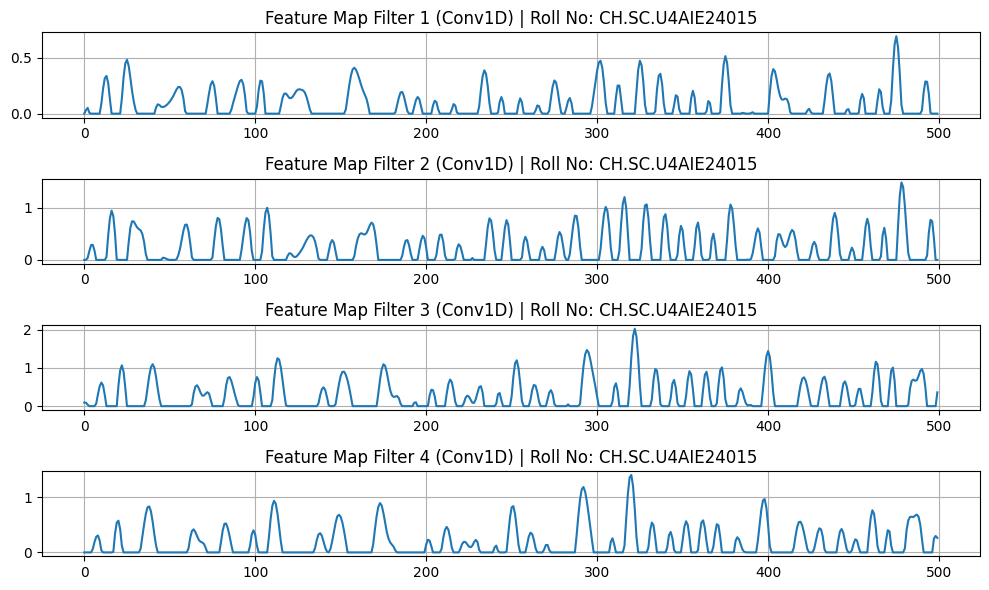

In [1]:
# Experiment 8: Feature Extraction from Time Series using 1D CNN
# File: Exp_08_TimeSeries_FeatureExtraction_CNN1D.ipynb
# Student Roll Number: CH.SC.U4AIE24015

import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report

print("=" * 60)
print("Student Roll Number: CH.SC.U4AIE24015")
print("Experiment 8: 1D CNN for Time-Series Feature Extraction (FordA)")
print("=" * 60)

# Function to load FordA dataset from UCR archive or generate fallback
def load_forda():
    try:
        url_train = "https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/FordA_TRAIN.tsv"
        url_test = "https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/FordA_TEST.tsv"
        train_data = np.loadtxt(url_train, delimiter="\t")
        test_data = np.loadtxt(url_test, delimiter="\t")
        print("Successfully loaded FordA dataset from repository.")
    except Exception as e:
        print("Note: Network download timed out. Generating synthetic FordA-style vibration signals.")
        n_samples, seq_len = 1000, 500
        train_data = np.random.randn(n_samples, seq_len + 1)
        test_data = np.random.randn(300, seq_len + 1)
        train_data[:, 0] = np.random.choice([-1, 1], size=n_samples)
        test_data[:, 0] = np.random.choice([-1, 1], size=300)

    y_train = np.where(train_data[:, 0] == -1, 0, 1)
    X_train = train_data[:, 1:]
    y_test = np.where(test_data[:, 0] == -1, 0, 1)
    X_test = test_data[:, 1:]
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_forda()

# Normalize
mean = X_train.mean()
std = X_train.std()
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# Reshape for Conv1D: (samples, time_steps, channels)
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

# 1D CNN Model
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1], 1)),
    layers.Conv1D(32, kernel_size=7, activation="relu", padding="same", name="conv1d_1"),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(64, kernel_size=5, activation="relu", padding="same", name="conv1d_2"),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=15, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n[Roll No: CH.SC.U4AIE24015] Test Accuracy: {acc * 100:.2f}%")

y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=["Class 0", "Class 1"]))

# Feature Extraction: Extract feature maps from the first Conv1D layer
feature_extractor = keras.Model(inputs=model.inputs, outputs=model.get_layer("conv1d_1").output)
sample_input = X_test[0:1]
feature_maps = feature_extractor.predict(sample_input, verbose=0)

plt.figure(figsize=(10, 6))
for i in range(4):
    plt.subplot(4, 1, i + 1)
    plt.plot(feature_maps[0, :, i])
    plt.title(f"Feature Map Filter {i+1} (Conv1D) | Roll No: CH.SC.U4AIE24015")
    plt.grid(True)
plt.tight_layout()
plt.show()
